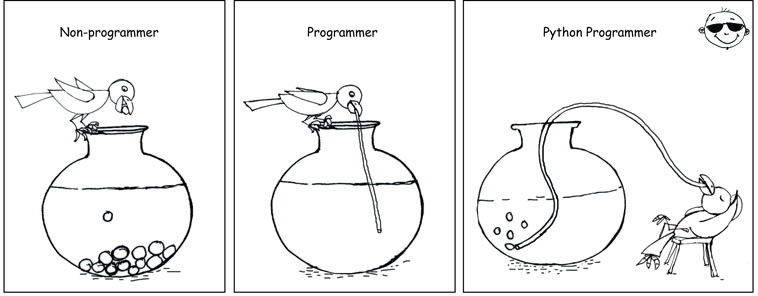

# **Application: Basic data analysis in python**

This notebook and the next will introduce the basics of python, using functions and formulae, wrangling data, and using common data analysis functions.


## Resources

https://catalog.libraries.psu.edu/catalog/29302927


# Introduction to the problem
An architectural engineer needs to understand the properties of the materials they use. One of the most common materials is concrete, and one of its most important properties is its compressive strength. To find this, we test a sample of the concrete in a lab.

In this experiment, a standard concrete cylinder is placed in a machine that applies a compressive force to it. As the force increases, the concrete deforms (this is called strain), until it eventually breaks. We will be analyzing the data from one of these tests to determine the strength of our concrete sample.

With this data you can find out a bunch of things like:

1. The stress on the concrete at each point in the test.

2. The relationship between stress and strain.

You can also use this data to make trendlines to figure out:

* The Modulus of Elasticity (a measure of the material's stiffness).

* The ultimate compressive strength of the concrete.

Let's get going! Here is the data from the experiment. We'll start by storing it in Python lists.

In [ ]:
# Strain and Force data from the concrete compression test
# Strain is unitless (in/in) and Force is in pounds (lb)
strain = [0.00014106, 0.00028212, 0.00041814, 0.00051385, 0.00066499, 0.00076071, 0.00087154, 0.00092695, 0.00108312, 0.00120907, 0.00144584, 0.00164736, 0.00192443, 0.00229219, 0.00260957, 0.00301259, 0.00325441, 0.00362217, 0.00378841, 0.00407053]
force = [3945.54974, 8548.6911, 12494.2408, 14993.089, 18807.1204, 21042.9319, 23410.2618, 24856.9634, 27487.3298, 30512.2513, 33142.6178, 36693.6126, 36956.6492, 38008.7958, 38008.7958, 36167.5393, 34457.801, 31038.3246, 27750.3665, 25514.555]

In [ ]:
# print the lists to make sure they look right
print("Strain (in/in):", strain)
print("Force (lb):", force)

Strain (in/in): [0.00014106, 0.00028212, 0.00041814, 0.00051385, 0.00066499, 0.00076071, 0.00087154, 0.00092695, 0.00108312, 0.00120907, 0.00144584, 0.00164736, 0.00192443, 0.00229219, 0.00260957, 0.00301259, 0.00325441, 0.00362217, 0.00378841, 0.00407053]
Force (lb): [3945.54974, 8548.6911, 12494.2408, 14993.089, 18807.1204, 21042.9319, 23410.2618, 24856.9634, 27487.3298, 30512.2513, 33142.6178, 36693.6126, 36956.6492, 38008.7958, 38008.7958, 36167.5393, 34457.801, 31038.3246, 27750.3665, 25514.555]


#Using formulae
First, we need to calculate the **stress** on the concrete. Stress is defined as the force applied per unit area:

$$ \sigma = \frac{F}{A} $$

Where:
- $\sigma$ (sigma) is the stress
- $F$ is the force
- $A$ is the cross-sectional area of the concrete cylinder

Our concrete cylinder has a diameter of 4 inches. The area is given by:

$$ A = \pi r^2 $$

Let's calculate the stress for each data point.

In [ ]:
# Define constants for the test
# your turn!
# define the variable for the diameter

# ADD CODE HERE

# calculate the radius based on that variable

# ADD CODE HERE

Now we need to calculate the cross-sectional area of the cylinder in square inches
$A = \pi * r^2$
an easy way to access $\pi$ is to import numpy for math functions

Numpy is a popular library for scientific computing that contains fast and convenient functions for doing math in Python.
Let's start by importing the [`numpy` module](https://numpy.org/doc/stable/) (like we did with `matplotlib` last time).
This will give access to all the features the `numpy` authors have implemented for us.
Remember using `import`, you can rename things with the [`as` keyword](https://www.w3schools.com/python/ref_keyword_as.asp).
This way you can have a shorthand for functions or modules you reference frequently.
Trust me, this will be worth it -- we are going to reference `numpy` in almost every line!

In [ ]:
import numpy as np
area = np.pi * radius**2
print("Cylinder Area: ", area, "in^2")

Cylinder Area:  12.566370614359172 in^2


Then we need to use this to calculate our stress!

In [ ]:
# so lets just do the equation stress = force / area
stress = force / area

TypeError: unsupported operand type(s) for /: 'list' and 'float'

But what went wrong?

The code above produced a TypeError. This is because standard Python lists (like our force list) do not support element-wise mathematical operations. You can't simply divide a whole list by a single number!

To perform these kinds of calculations, we need to use NumPy arrays. An array is a special data structure designed for efficient numerical computation. By converting our force list into a NumPy array, we can then divide every element in the array by our area value in a single, clean operation.

In [ ]:
# convert the force list to a numpy array
force_array = np.array(force)

# calculate stress (sigma) for each data point
stress = force_array / area

# show me what I calculated
print("Stress (psi):", stress)

Stress (psi): [ 313.97687217  680.28322277  994.26009175 1193.11211328 1496.62308849
 1674.54331452 1862.92944227 1978.05429768 2187.37220503 2428.08780963
 2637.40572494 2919.98491259 2940.91670015 3024.64386627 3024.64386627
 2878.12132953 2742.06467861 2469.95139269 2208.30400054 2030.38377452]


#What does the data look like?

Let's plot this data in python using a matplotlib scatter plot with Strain on the x-axis and Stress on the y-axis.

Make sure your plot has the axes labeled and includes a title. Make it so that the individual measurements are dots that are not connected with lines (in the documentaito for matplotlib you will want to look at the keyword arguments like marker and linestyle to do this!)

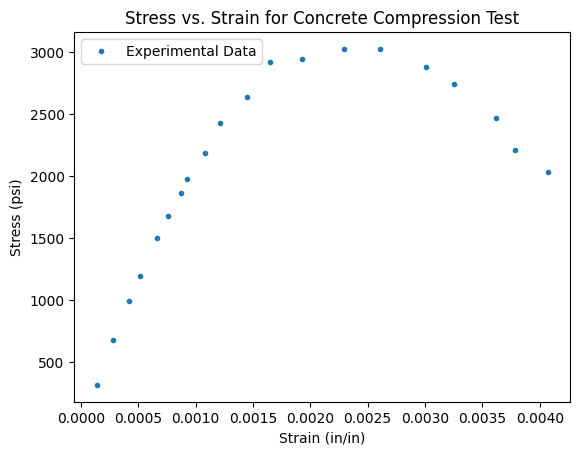

In [ ]:
# Look back at your code from session 2: create a scatter plot of stress vs strain
# Don't forget: labels, title, and markers without connecting lines

import matplotlib.pyplot as plt
# ADD CODE HERE

## Creating a Regression Line
The relationship between stress and strain appears to be linear at the beginning of the test; the **elastic region**, where the material behaves predictably. The slope of this line is the **Modulus of Elasticity**, a critical material property for structural engineers.

> **Note on the data:** In Sessions 1 & 2 you worked with the first 8 load steps. The full dataset here has 20 points; the test continued past the elastic region into plastic deformation and eventual failure. We'll use only the first 8 points for the regression.

To find this slope, we will perform a linear regression on the first 8 data points.

In [ ]:
from scipy import stats # scipy is another python package like numpy!

# The relationship is only linear for the first part of the test (elastic region).
# Let's use the first 8 data points for our linear regression.
strain_linear = np.array(strain[:8])
stress_linear = np.array(stress[:8])

# Perform the linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(strain_linear, stress_linear)

# The slope of this line is the Modulus of Elasticity
modulus_of_elasticity = slope

print("Modulus of Elasticity (Slope):", modulus_of_elasticity, "psi")
print("Y-intercept:", intercept, "psi")
print("R-squared value:", r_value**2)

Modulus of Elasticity (Slope): 2076572.790169705 psi
Y-intercept: 85.55100881724752 psi
R-squared value: 0.9955998574187722


Now that we have the slope and intercept of our trendline, we can plot the equation to see how it fits our data.

Notice: instead of a for loop, the line below multiplies a numpy array by a number directly. This is called **broadcasting**; numpy applies the operation to every element at once. It only works because `strain_linear` is a numpy array (we converted it with `np.array()` in the cell above). A plain Python list would raise an error here, just like it did when we divided `force / area` earlier.

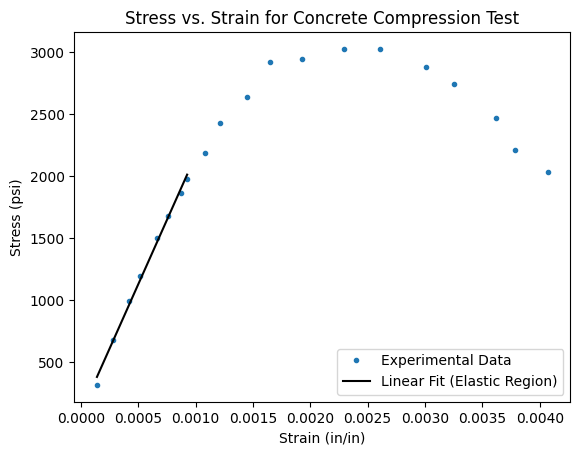

In [ ]:
# Calculate stress_model using y = mx + b (numpy broadcasting shown in the note above)
# Then add the model line to the existing figure

# ADD CODE HERE

You can save your figure to a file using `savefig()`:

```python
fig_concrete.savefig('Concrete_Test_Plot.png')
```

#Evaluating our Model

The $R^2$ value is very close to 1, which tells us our linear model is a good fit for the elastic region. Another way to check our model's accuracy is by calculating the residuals. A residual is the difference between an observed data point and the value predicted by our model.

Residual = Actual Stress - Predicted Stress

Let's calculate the residuals and their standard deviation for the linear portion of our data. A smaller standard deviation indicates a better fit.

In [ ]:
# Residuals tell us the difference between our model and the actual data.
residuals = stress_linear - stress_model
print("Residuals (psi):", residuals)

Residuals (psi): [-64.49549443   8.88949839  40.41093645  40.51417624  30.17193994
   9.32261849 -32.43781609 -32.37585898]


In [ ]:
# The standard deviation of the residuals gives us an idea of the average error of our model.
std_dev_residuals = np.std(residuals)
print("Standard Deviation of Residuals:", std_dev_residuals, "psi")

Standard Deviation of Residuals: 36.419087675971035 psi


## Visualizing Model Error with Error Bars
The standard deviation of the residuals that we calculated gives us a single number representing the average error of our model. A powerful way to visualize this error on our plot is with **error bars**.

We'll add error bars to each data point in the elastic region. The bar height (up/down) equals the standard deviation of the residuals; it shows how much, on average, each point deviates from the fit.

Instead of creating a brand-new figure, we'll **add to the figure we already have** (`fig_concrete`). We just call `ax_concrete.errorbar()` directly; the original scatter and model line are still there.

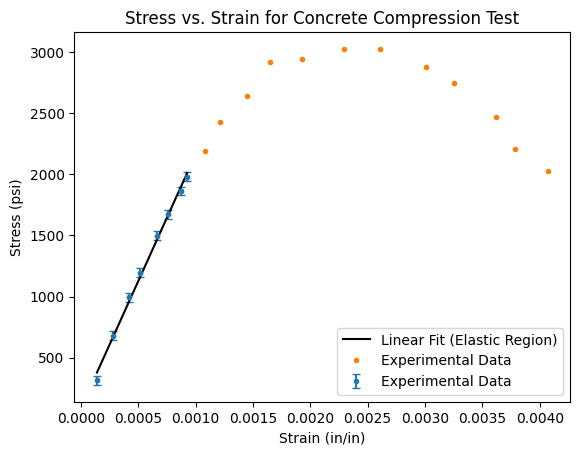

In [ ]:
# Add error bars to the elastic data points using ax_concrete.errorbar()
# yerr should be the standard deviation of the residuals
# Don't forget: legend and display the figure

# ADD CODE HERE

Now that we have this visualization, let's think like engineers!

**In-class assignment:** Take a screengrab of your code and output and submit to Canvas.

Your plot should show:
- All 20 data points (full compression test)
- The linear fit line through the elastic region (first 8 points)
- Error bars on the elastic data points showing ± one standard deviation of the residuals
- Axis labels and a title

#Observational Questions (What do you see?)
"Based on the plot, what is the approximate ultimate compressive strength of this concrete sample (i.e., the highest stress it reached before failing)?"

"What happens to the stress after it reaches its highest point?"

"Look at the y-intercept value from the regression. Is it exactly zero? Why might a real-world test not start at a perfect (0,0) point?"

#Interpretive Questions (What does it mean?)
"Why did we only perform the linear regression on the first 8 points and not the entire dataset?"

"What does the Modulus of Elasticity (the slope) tell us about this specific concrete? Would a higher number mean the concrete is stiffer or more flexible?"

"The R-squared value was very high (close to 1). What does this tell you about how well the linear equation models the material's behavior in that initial region?"

#Applied & Analytical Questions (Why does it matter & What's next?)
"An engineer wants to use this concrete for a column that should never experience more than 1500 psi of stress to be safe. Based on your linear model, what is the maximum strain the column should be allowed to deform?"

"Look at your plot with the error bars. Do the data points in the non-linear (curved) section of the graph fall within the error bars calculated from the linear model? What does this visually confirm about the model's limitations?"

"How would an architectural engineer use the ultimate compressive strength and the Modulus of Elasticity when designing a building?"

# **Another example**

Woohooo! You've successfully performed a basic engineering analysis and visualization in Python. This type of analysis is fundamental in architectural engineering for understanding material properties.

Now that we have gone through an initial example, here is how I would go through a slightly more challenging one. The main difference between the problem we just did and this next one is that we will use a for loop (we talked about these last class!)

A for loop is a powerful tool in programming used for iterating over a sequence (like a list) and performing an action for each item in that sequence.

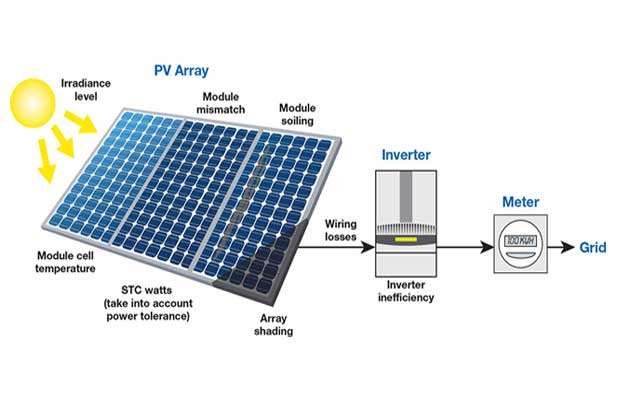

source = https://www.saurenergy.com/solar-energy-blog/here-is-how-you-can-calculate-the-annual-solar-energy-output-of-a-photovoltaic-system

An architectural engineer is evaluating different sizes of solar panels for a building project. To calculate how efficient a solar panel is, you can use this formula:

To calculate how efficient a solar panel is you can use this formula:


$E = \frac{Pmax}{Area}\times STC \div 1000$


where:

Efficiency $= E (\%)$

Solar panel peak power $=Pmax (Watts)$

Area  $= A (m^2)$

Standard test condition $= STC (W/m2)$

Given conditions: $STC = 100$ and $Pmax = 285 W$

The following conditions were given to you:



In [ ]:
A = [10,30,40, 50, 60]

Your task is to use a for loop to calculate the efficiency for each panel area and then plot the results.

In [ ]:
# First, let's define our constants
p_max = 285
stc = 100

In [ ]:
# Create an empty list to store our calculated efficiencies
calculated_efficiency = []

# Loop over each area value in our list A
for area_val in A:
  # Apply the formula to calculate efficiency for the current area
  E = (p_max / area_val) * stc / 1000
  # Add the calculated efficiency to our results list
  calculated_efficiency.append(E)

In [ ]:
# Print the final list of efficiencies to check our work
print("Calculated Efficiencies (%):")
print(calculated_efficiency)

Now, create a scatter plot of the calculated_efficiency vs. the Area (A). Don't forget to label your axes and give the plot a title!

In [ ]:
# import the plotting library
import matplotlib.pyplot as plt # you dont need to do this every time you make a plot, just the first time in a notebook FYI

# create the figure and axes
figure_solar, axis_solar = plt.subplots()

# Add labels and a title
axis_solar.set_xlabel('Area (m2)')
axis_solar.set_ylabel('Efficiency (%)')
axis_solar.set_title('Solar Panel Efficiency vs. Area')

# Plot the data using markers, not a line
axis_solar.plot(A, calculated_efficiency, marker='.', linestyle='none')

Now that we've plotted our data, we can see a clear trend. To quantify this relationship, we can perform a linear regression. This will give us an equation for a line (y=mx+b) that best fits our data points. The equation will help us model how a solar panel's efficiency changes with its area.

First, we'll use the linregress function from the scipy.stats library to calculate the slope, intercept, and R-squared value for our data.


In [ ]:
# The stats library should already be imported, but we'll include it again for clarity
from scipy import stats

# Perform the linear regression on Area (A) and our calculated efficiency
solar_results = stats.linregress(A, calculated_efficiency)

# Print the results object to see all the calculated values
print(solar_results)

Then, using the slope and intercept from our regression results, we can now create a new list of "modeled" efficiency values. We'll use a for loop to calculate the predicted efficiency for each area according to our new linear equation.

In [ ]:
# Create an empty list for the model efficiency values
E_model = []

# For each area, calculate what the model's efficiency value would be
for area_val in A:
  # Use the equation y = mx + b, where x is our area_val
  y = solar_results.slope * area_val + solar_results.intercept
  # Add the calculated model value to our list
  E_model.append(y)

# Plot the model as a black line on our existing chart
axis_solar.plot(A, E_model, color='k', label='Linear Fit')

# Add a legend to show both the data and the model
axis_solar.legend()

# Show the final figure with both the data points and the trendline
figure_solar

In [ ]:
# Calculate the residuals for the solar panel data
# Residual = Actual Efficiency - Predicted Efficiency
residuals_solar = calculated_efficiency - (solar_results.slope * np.array(A) + solar_results.intercept)

# Calculate the standard deviation of these residuals
std_dev_residuals_solar = np.std(residuals_solar)

print("Solar Model Residuals (%):")
print(residuals_solar)
print() # blank line for readability
print("Standard Deviation of Solar Residuals:", round(std_dev_residuals_solar, 4))

In [ ]:
# import the plotting library
import matplotlib.pyplot as plt

# create the figure and axes
figure_solar, axis_solar = plt.subplots()

# Add labels and a title
axis_solar.set_xlabel('Area (m2)')
axis_solar.set_ylabel('Efficiency (%)')
axis_solar.set_title('Solar Panel Efficiency vs. Area')

# Plot the experimental data WITH error bars
# yerr is set to our calculated standard deviation
axis_solar.errorbar(A, calculated_efficiency, yerr=std_dev_residuals_solar, marker='.', linestyle='none', label='Experimental Data')

# Plot the model as a black line on our existing chart
axis_solar.plot(A, E_model, color='k', label='Linear Fit')

# Add a legend to show both the data and the model
axis_solar.legend()

So now that we have this data and this visualization! Let's start to think like engineers! What types of questions and statements can we ask looking at this?

#Observational Questions (What do you see?)

"Looking at the dots, what happens to the efficiency as the area of the solar panel increases?"

"What does the black line on the plot represent?"

"According to the legend, what does the black line represent? What do the blue dots represent?"

"What is the R-squared value for our linear fit, and what does a value close to 1 (or -1) generally mean?"


# Interpretive Questions (What does it mean?)

"Does our linear model seem to be a good fit for this data? How does the R-squared value support your answer?" ****

"Why does the efficiency decrease as the area gets larger, assuming the peak power (Pmax) stays the same? What does that imply for an architectural engineer choosing panels for a limited roof space?"

"What is the physical meaning of the slope in this model? What would the y-intercept represent in a real-world scenario?"

#Applied & Analytical Questions (Why does it matter & What's next?)
"Using the slope and intercept from our model, what would you predict the efficiency to be for a solar panel with an area of 70 m²?"

"Would you trust this linear model to predict the efficiency for a panel with a very small area, like 1 m²? Why or why not?"

"In the previous concrete example, we only used the linear part of the data for our regression. Here, we used all the data. Why was that an appropriate decision for this dataset?"

"If you were an engineer with a goal of maximizing total energy production for a fixed budget (not just efficiency), would you choose a few large panels or many small panels based on this data? What other information would you need?"

#Key Takeaways

In this lesson, you performed a complete data analysis workflow that is common in engineering: Data handling --> visualization --> modeling --> evaluation!

**Data haandling:** You started with raw data in Python lists and used NumPy to perform mathematical calculations and convert lists into powerful arrays.

**Visualization** You used Matplotlib to create a scatter plot to visually inspect the relationship between stress and strain.

**Modeling**: You used SciPy to perform a linear regression on a key portion of the data to find the Modulus of Elasticity.

**Evaluation**: You validated your model by calculating residuals and their standard deviation, then visualized this uncertainty using error bars.